<a href="https://colab.research.google.com/github/Tiiso/ISM8X04-Assignment1/blob/main/220003917_SM8X04_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

In [ ]:
# 1. DATA SOURCE & LOADING
# The dataset contains 32,581 instances and 12 features [cite: 410, 526, 544]
df = pd.read_csv('credit_risk_dataset.csv')

In [ ]:
# 2. EXPLORATORY DATA ANALYSIS (EDA) & CLEANING
# Addressing outliers: person_age > 100 is biologically impossible
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

# 3. DATA ENCODING [Section 2.4]
# Label Encoding for binary features [cite: 101, 453]
le = LabelEncoder()
df['cb_person_default_on_file'] = le.fit_transform(df['cb_person_default_on_file'])

# One-Hot Encoding for categorical variables without intrinsic order [cite: 101, 454]
# Applied to person_home_ownership, loan_intent, and loan_grade
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. MISSING DATA IDENTIFICATION & IMPUTATION [Section 2.5]
# Identifying numerical columns for imputation
num_cols = ['person_emp_length', 'loan_int_rate']

In [ ]:
# A. Median Imputation for person_emp_length (Robust against skewness)
median_imputer = SimpleImputer(strategy='median')
df['person_emp_length'] = median_imputer.fit_transform(df[['person_emp_length']])

# B. KNN Imputation for loan_int_rate (Preserves multi-dimensional relationships) [cite: 145, 413]
# KNN identifies 'similar' borrowers to fill missing interest rates
knn_imputer = KNNImputer(n_neighbors=5)
df[num_cols] = knn_imputer.fit_transform(df[num_cols])

In [ ]:
# 5. FEATURE SCALING
# Z-score normalization improves convergence [cite: 102, 103]
scaler = StandardScaler()
X = df.drop('loan_status', axis=1)
y = df['loan_status']
X_scaled = scaler.fit_transform(X)

In [ ]:
# 6. TRAIN-TEST SPLIT
# Stratified 70-30 split to maintain default/non-default ratio [cite: 93, 298]
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42
)

In [ ]:
# 7. CLASS IMBALANCE HANDLING
# Applying SMOTE to resolve the 1:4 default ratio
# SMOTE generates synthetic minority samples [cite: 105, 106, 434]
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# 8. PREDICTIVE MODELING - RANDOM FOREST
# Random Forest construction via bootstrap aggregation (bagging) [cite: 114, 115, 423]
# Selected for robustness and built-in variable importance [cite: 119, 427, 479]
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=10, random_state=42)

In [ ]:
# 9. PERFORMANCE EVALUATION [cite: 193, 195, 451]
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC Score: 0.9242

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      7456
           1       0.81      0.75      0.78      2048

    accuracy                           0.91      9504
   macro avg       0.87      0.85      0.86      9504
weighted avg       0.90      0.91      0.91      9504



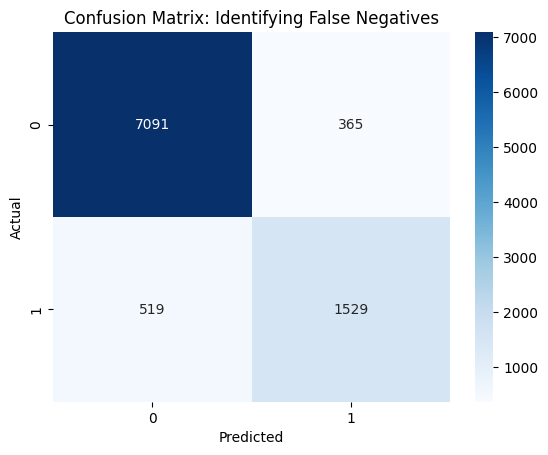

In [ ]:
# 10. ERROR ANALYSIS via Confusion Matrix [cite: 161, 220, 445]
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Identifying False Negatives')
plt.show()